# D3: what force does a collapsing vortex require?
The momentum residual measures the force per unit mass required by a chosen velocity and pressure.
We evaluate the explicit exterior in the paper's Eq. (4.29), and a separately labelled Gaussian toy.
The full inner core and matching annulus are not reconstructed. All units are dimensionless.

In [1]:
from pathlib import Path
import csv, json
import numpy as np
from IPython.display import display, Markdown, Image
from nscomp.residual import HeatExterior, gaussian_terms, gaussian_force_l2
from nscomp.d3 import load_parameters, models, generate, term_table, WRITING, STUDY
p=load_parameters()
exterior,toy=models(p)
summary=generate()
print(json.dumps(summary,indent=2))

{
  "heat_max_angular_normalized_residual": 5.5554809508181615e-15,
  "heat_max_sampled_residual_magnitude": 2.764863893389702e-10,
  "heat_max_raw_laplacian_relative_difference": 8.011840080257571e-10,
  "gaussian_reference_force_magnitude": 3.149918299259421,
  "gaussian_reference_force_l2": 15.905536191376514,
  "gaussian_force_growth_factor": 999999999999.9999,
  "gaussian_l2_growth_factor": 1000000.0000000001,
  "best_time_finite_difference_error": 1.0476579248575035e-07,
  "last_quadrature_derivative_relative_error": 3.774758283725532e-15,
  "full_background_assembled": false,
  "parameters_sha256": "8bc48f636e5cb62d0a22a65573989e9d830dc1a9bfff46830e1f415235620150"
}


## 1. Read the signed terms
$R=u_t+(u\cdot\nabla)u-\Delta u+\nabla p$ at viscosity one.
The radial transport component of a pure swirl is $-u_\theta^2/r$.
The vector Laplacian has the angular term $-u_\theta/r^2$ as well as scalar derivative terms.
All components and pressure conventions are documented in the article.

| Term | Heat exterior, radial | Heat exterior, angular | Gaussian toy, angular | Gaussian toy, axial |
| --- | --- | --- | --- | --- |
| Local acceleration | 0 | 8.045e-07 | 10.47 | 0 |
| Transport | -0.3494 | 0 | 0 | 0 |
| Pressure gradient | 0.3494 | 0 | 0 | 6.157 |
| Minus viscosity | 0 | -8.045e-07 | 88.95 | 0 |
| Sum / required force | 0 | 8.788e-21 | 99.42 | 6.157 |

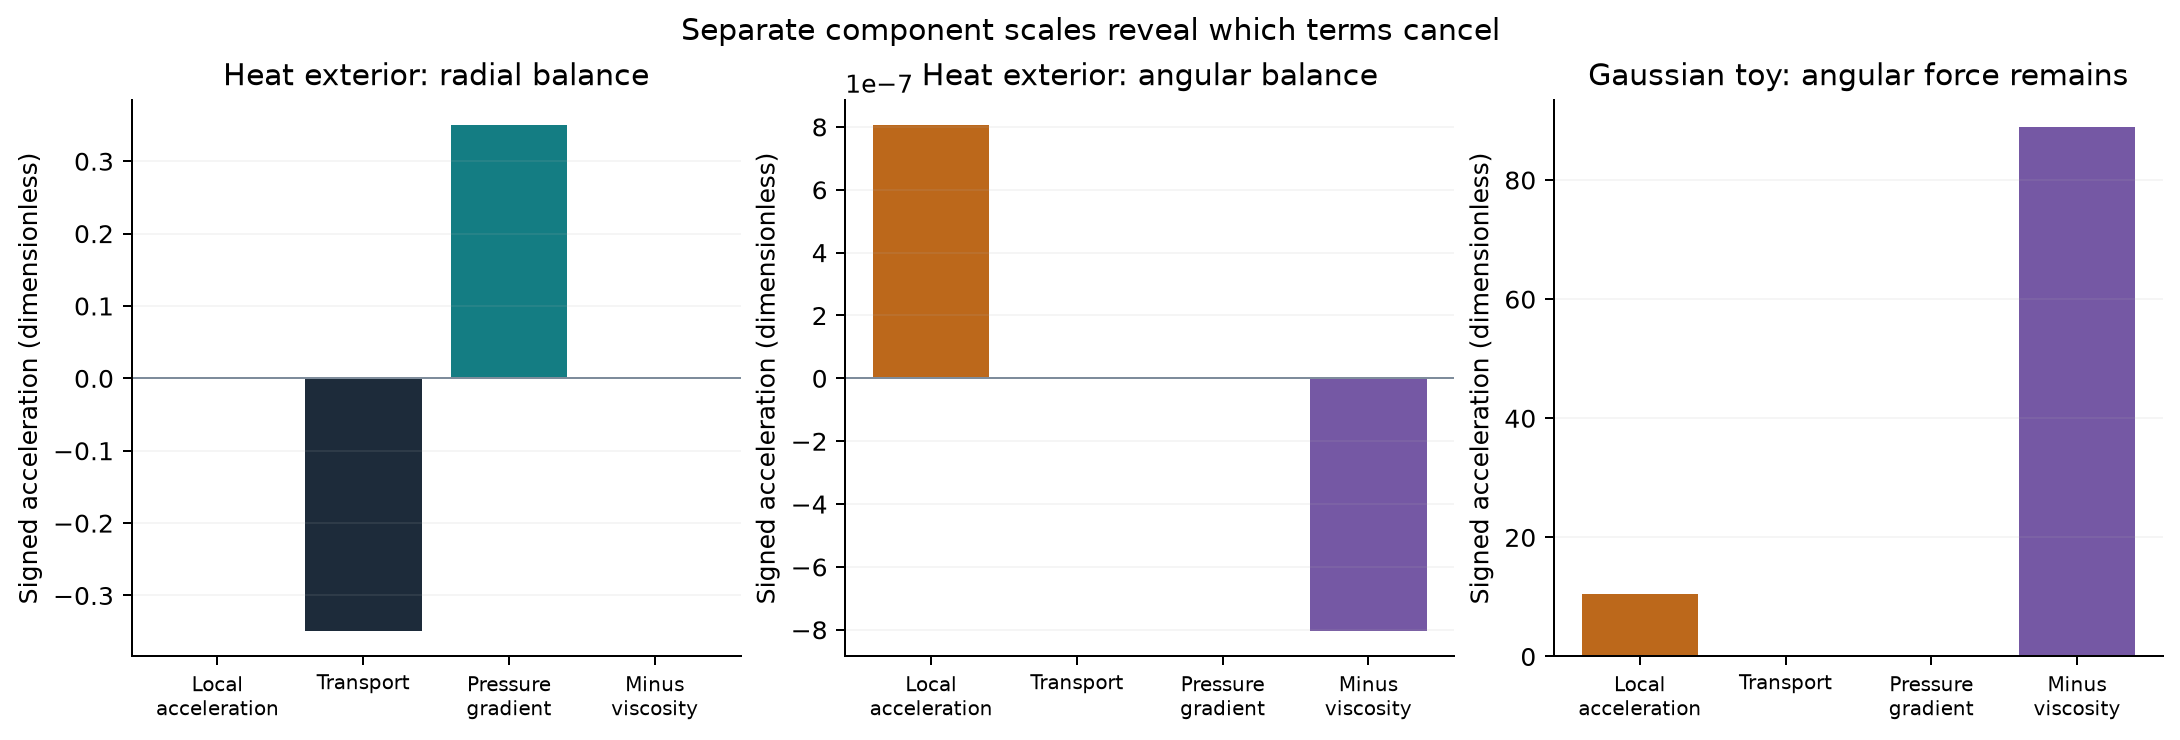

In [2]:
display(Markdown(term_table(p)))
display(Image(filename=str(WRITING/'figures/01_momentum_terms.png')))

## 2. The explicit heat exterior
Pressure tends to zero at radial infinity. Its radial gradient balances centrifugal acceleration.
The angular velocity solves the radial heat equation on positive radius. The matching boundary Xb
and complete profile parameters are uncomputed. A small numerical residual checks this explicit
family, not the whole construction.

In [3]:
tau=0.1
radius=np.sqrt(2*tau*16)
print("Velocity:",exterior.velocity(radius,tau))
print("Pressure integral:",exterior.pressure(radius,tau))
print("Physical-coordinate derivatives:",exterior.derivatives(radius,tau))
print("Residual components:",exterior.terms(radius,tau)["residual"])
print("Normalized components:",exterior.terms(radius,tau)["component_normalized"])

Velocity: 0.7905689547068057
Pressure integral: -0.31249904496426806
Physical-coordinate derivatives: {'velocity': np.float64(0.7905689547068057), 'time': np.float64(8.045064438906852e-07), 'radial': np.float64(-0.44194227484274945), 'radial_second': np.float64(0.4941068450221415), 'laplacian': np.float64(8.045064438906764e-07), 'raw_laplacian': np.float64(8.045064439909932e-07)}
Residual components: [0.00000000e+00 8.78796683e-21 0.00000000e+00]
Normalized components: [0.00000000e+00 5.46171314e-15 0.00000000e+00]


## 3. The Gaussian toy needs an unbounded force
At the fixed marker R=1,Z=0.5, force magnitude grows as tau^(-3/2) in the h=0 limit.
Its L2 force norm on 0<r<8a and |z|<8b grows as tau^(-3/4).
The decreasing kinetic energy in D2 does not make this force smooth through tau=0.

tau 1 force magnitude 3.149918299259421 L2 force 15.905536191376514
tau 0.01 force magnitude 3149.91829925942 L2 force 502.97721770989597
tau 0.0001 force magnitude 3149918.299259421 L2 force 15905.536191376515


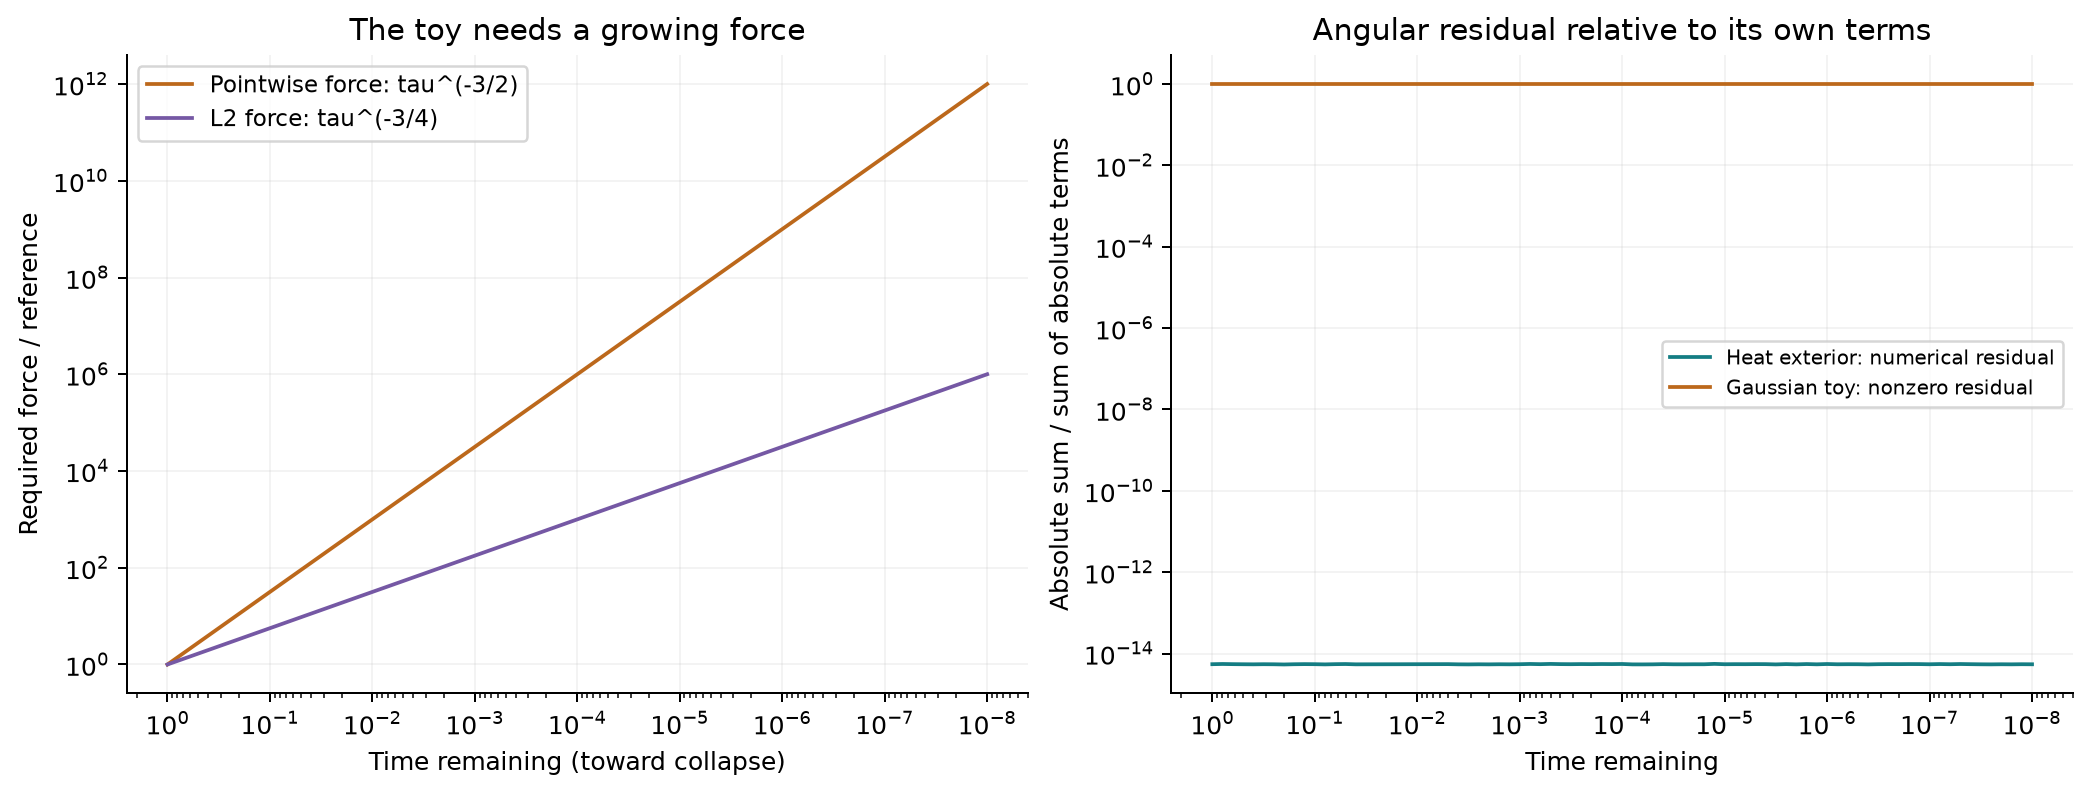

In [4]:
for tau in (1,1e-2,1e-4):
    a,b,U=toy.widths_and_speed(tau)
    force=gaussian_terms(a,0.5*b,tau,toy)["residual"]
    print("tau",tau,"force magnitude",np.linalg.norm(force),"L2 force",gaussian_force_l2(tau,toy))
display(Image(filename=str(WRITING/'figures/02_required_force.png')))

## 4. Quadrature and differentiation checks
The quadrature study compares the profile and its derivative with 60-digit integration.
The finite-difference study changes the step in physical radius and physical time.
An excessively small step can make a derivative worse by subtracting nearly equal velocities.

{'order': '8', 'profile_relative_error': '8.933964679158635e-13', 'profile_derivative_relative_error': '1.8946155789789643e-05', 'angular_normalized_residual': '4.0126842609454346e-05'}
{'order': '12', 'profile_relative_error': '2.1760371282653068e-14', 'profile_derivative_relative_error': '5.880017708292939e-07', 'angular_normalized_residual': '1.4974111008102758e-06'}
{'order': '16', 'profile_relative_error': '8.881784197001252e-16', 'profile_derivative_relative_error': '3.055644404170721e-08', 'angular_normalized_residual': '8.900815407055523e-08'}
{'order': '24', 'profile_relative_error': '0.0', 'profile_derivative_relative_error': '2.066051774107791e-10', 'angular_normalized_residual': '7.300153767758629e-10'}
{'order': '32', 'profile_relative_error': '0.0', 'profile_derivative_relative_error': '2.9947155866238973e-12', 'angular_normalized_residual': '1.2159728295710167e-11'}
{'order': '48', 'profile_relative_error': '1.1102230246251565e-16', 'profile_derivative_relative_error': '

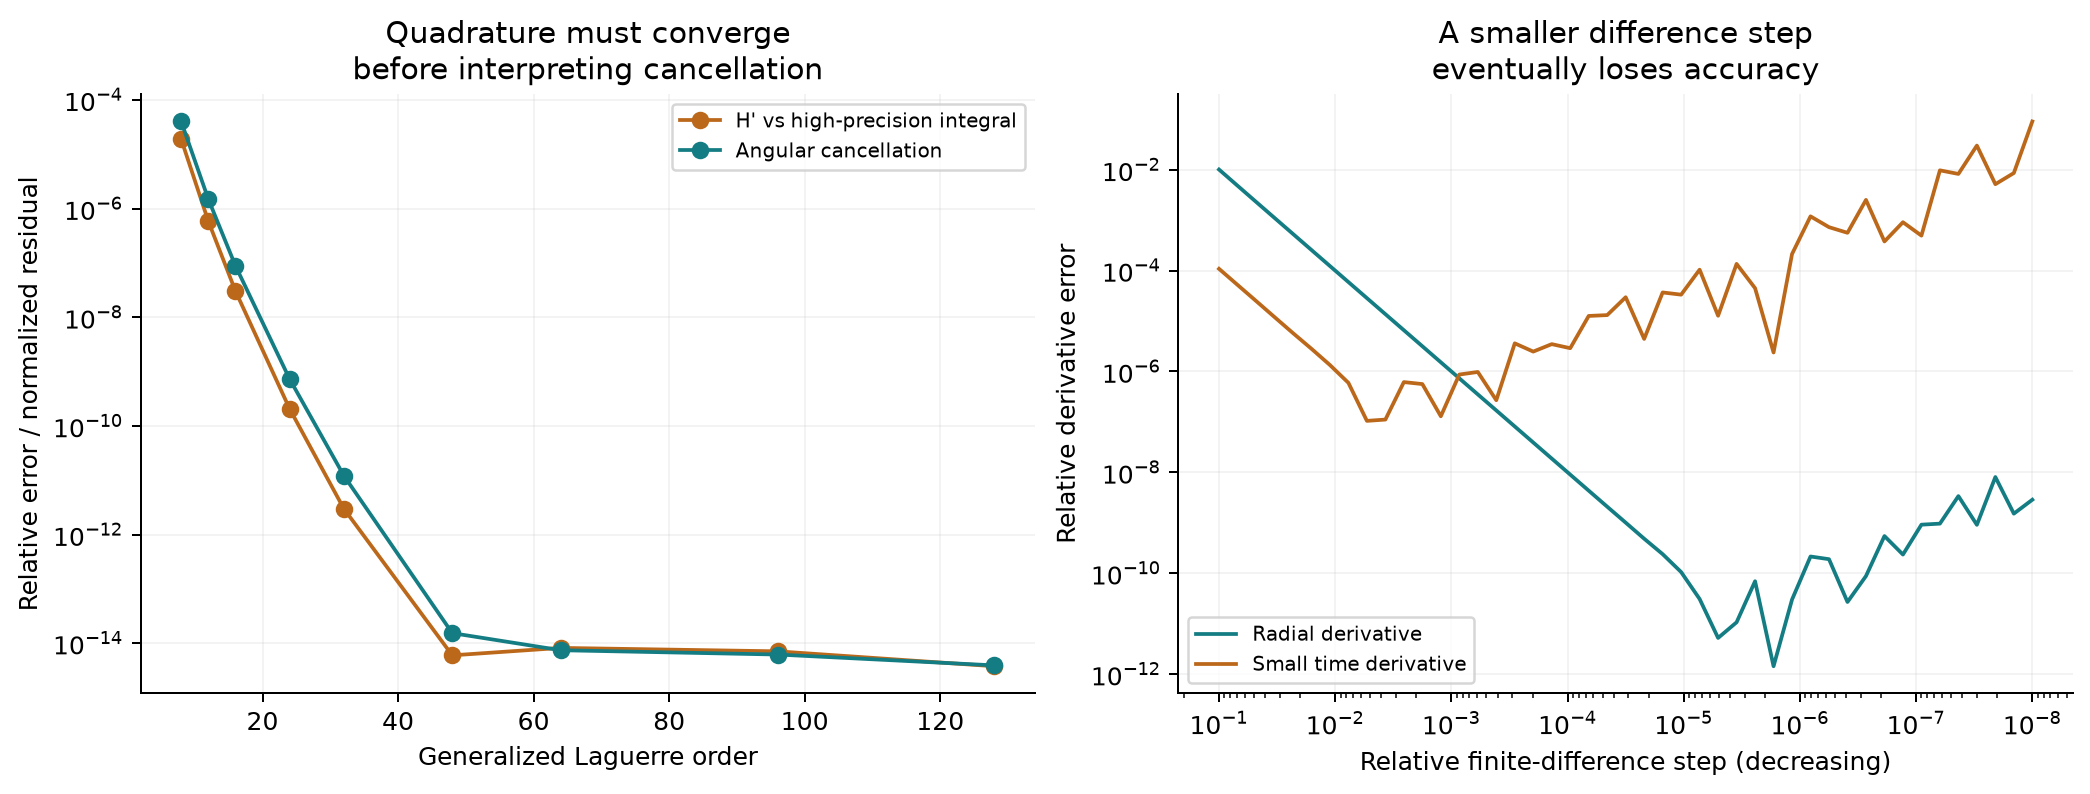

In [5]:
with (STUDY/'data/quadrature_convergence.csv').open() as stream:
    convergence=list(csv.DictReader(stream))
for row in convergence:
    print(row)
display(Image(filename=str(WRITING/'figures/03_numerical_checks.png')))

## 5. Explore the exterior family
The h=0 limit is a steady inverse-radius swirl. Other values below are mathematical exterior
examples, not validated choices from the complete proof hierarchy. Larger h generally makes
the small time derivative easier to resolve in ordinary precision.

In [6]:
for h in (0,1e-6,0.005):
    candidate=HeatExterior(h=h,order=128)
    d=candidate.derivatives(2.1,0.12)
    print("h=",h,"velocity=",d["velocity"],"time derivative=",d["time"],
          "angular normalized residual=",candidate.terms(2.1,0.12)["component_normalized"][1])

h= 0 velocity= 0.6734350297014738 time derivative= 0.0 angular normalized residual= 0.0
h= 1e-06 velocity= 0.6734344305439047 time derivative= 5.08748568588131e-07 angular normalized residual= 2.7055182545438492e-15
h= 0.005 velocity= 0.6704443788968291 time derivative= 0.0025430503442854194 angular normalized residual= 8.100445720044593e-15


## Scope of the evidence
The tests independently check profile integration, physical-coordinate derivatives, the pressure
integral, Cartesian divergence, the vector Laplacian, and Gaussian-force growth.
Numerical cancellation is not a proof that a full force and all its derivatives extend smoothly.
See ../../writing/d3_residual/source-notes.md for source locations and limitations.